QUESTION 1: ADQL QUERY

SELECT DISTINCT
    gaia.source_id,
    gaia.ra,
    gaia.dec,
    gaia.parallax,
    gaia.phot_g_mean_mag,
    gaia.bp_rp,

    tmass.designation AS tmass_id,
    tmass.ph_qual,
    tmass.j_m,
    tmass.h_m,
    tmass.ks_m

FROM gaiadr3.gaia_source AS gaia

JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS xmatch
    ON gaia.source_id = xmatch.source_id

JOIN gaiadr3.tmass_psc_xsc_join AS xjoin
    ON xmatch.clean_tmass_psc_xsc_oid = xjoin.clean_tmass_psc_xsc_oid

JOIN gaiadr1.tmass_original_valid AS tmass
    ON xjoin.original_psc_source_id = tmass.designation

WHERE
    CONTAINS(
        POINT('ICRS', gaia.ra, gaia.dec),
        CIRCLE('ICRS', 132.825, 11.8, 1.0)
    ) = 1

    AND gaia.phot_g_mean_mag < 14


Running Gaia DR3 query...

QUESTION 1 RESULT
Number of Gaia DR3 + 2MASS stars returned: 1018

QUESTION 2: QUALITY CUTS
Initial sample:                              1018
Bad 2MASS photometry (ph_qual != 'AAA'):   21
Non-positive Gaia parallax:                 

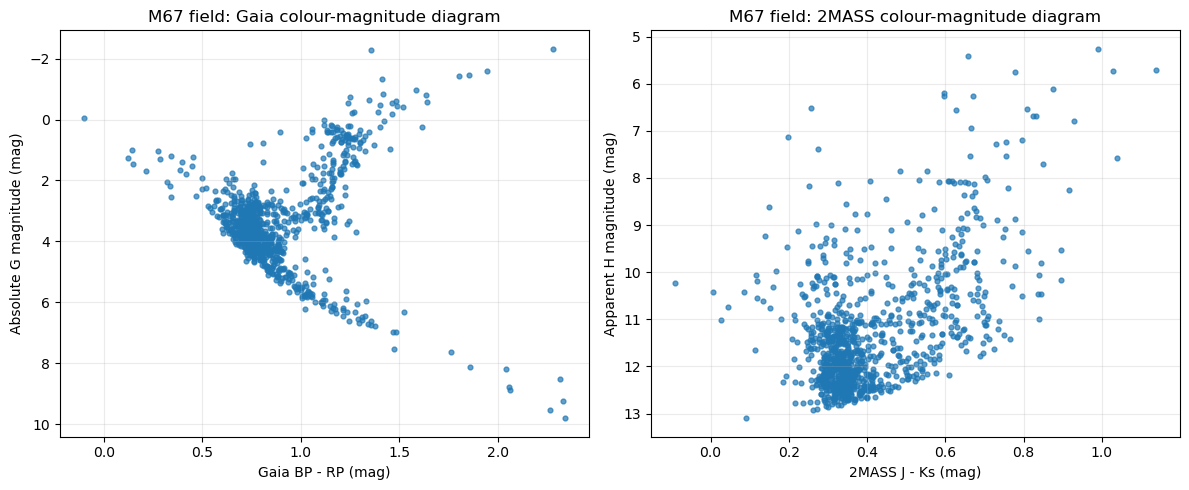


QUESTION 3 RESULT
Figure saved to:             figures/m67_gaia_2mass_cmd.png
Stars in final clean sample: 995
Stars plotted in Gaia CMD:   987
Stars plotted in 2MASS CMD:  995

QUESTION 4: 2dF/HERMES FIBRE USAGE
Qualified targets:                       995
Available 2dF/HERMES fibres:             392
Targets per available fibre:             2.54
Targets in first configuration:          392
First-configuration fibre usage:         100.0%
Configurations required for all targets: 3
Targets in final configuration:          211
Final-configuration fibre usage:         53.8%

Recommendation:
YES. Based only on fibre usage, this field is suitable for a 2dF/HERMES proposal. The number of quality-selected targets exceeds the available fibre count, so the first configuration can achieve 100% fibre usage.

SECTION 2 SUMMARY
Q1 - Gaia + 2MASS stars returned:       1018
Q2 - Bad 2MASS photometry:              21
Q2 - Non-positive parallaxes:           2
Q2 - Stars failing both criteria:       0
Q

In [4]:
# SECTION 2: BRIGHT STARS AROUND M67 WITH ADQL

import io
import os
import math
import urllib.parse
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# QUESTION 1: GAIA DR3 + 2MASS QUERY

# Coordinates of M67 in degrees.
ra_m67 = 132.825
dec_m67 = 11.8

# Searching within 1 degree of the cluster centre.
radius = 1.0


# ADQL query:
# - selects Gaia DR3 sources within 1 degree of M67
# - requires Gaia G < 14
# - crossmatches the sources with 2MASS
# - retrieves the quantities needed for Questions 2 and 3
query = f"""
SELECT DISTINCT
    gaia.source_id,
    gaia.ra,
    gaia.dec,
    gaia.parallax,
    gaia.phot_g_mean_mag,
    gaia.bp_rp,

    tmass.designation AS tmass_id,
    tmass.ph_qual,
    tmass.j_m,
    tmass.h_m,
    tmass.ks_m

FROM gaiadr3.gaia_source AS gaia

JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS xmatch
    ON gaia.source_id = xmatch.source_id

JOIN gaiadr3.tmass_psc_xsc_join AS xjoin
    ON xmatch.clean_tmass_psc_xsc_oid = xjoin.clean_tmass_psc_xsc_oid

JOIN gaiadr1.tmass_original_valid AS tmass
    ON xjoin.original_psc_source_id = tmass.designation

WHERE
    CONTAINS(
        POINT('ICRS', gaia.ra, gaia.dec),
        CIRCLE('ICRS', {ra_m67}, {dec_m67}, {radius})
    ) = 1

    AND gaia.phot_g_mean_mag < 14
"""


# Printing the ADQL query so it is included in the notebook.
print("=" * 70)
print("QUESTION 1: ADQL QUERY")
print("=" * 70)
print(query)


# Gaia TAP service used to run the ADQL query.
tap_url = "https://gea.esac.esa.int/tap-server/tap/sync"

# Setting the query parameters.
tap_parameters = {
    "REQUEST": "doQuery",
    "LANG": "ADQL",
    "FORMAT": "csv",
    "MAXREC": "100000",
    "QUERY": query
}

# Converting the parameters into an HTTP request.
post_data = urllib.parse.urlencode(tap_parameters).encode("utf-8")

request = urllib.request.Request(
    tap_url,
    data=post_data,
    headers={"User-Agent": "Mozilla/5.0"}
)

print("\nRunning Gaia DR3 query...")


# Sending the query and read the result.
with urllib.request.urlopen(request, timeout=300) as response:
    gaia_csv = response.read().decode("utf-8")

# Converting the returned catalogue to a pandas DataFrame.
m67 = pd.read_csv(io.StringIO(gaia_csv))

# Counting the stars returned by the original query.
n_initial = len(m67)


print("\n" + "=" * 70)
print("QUESTION 1 RESULT")
print("=" * 70)

print(f"Number of Gaia DR3 + 2MASS stars returned: {n_initial}")


# Converting the required catalogue columns to numerical values.
numeric_columns = [
    "ra",
    "dec",
    "parallax",
    "phot_g_mean_mag",
    "bp_rp",
    "j_m",
    "h_m",
    "ks_m"
]

for column in numeric_columns:
    m67[column] = pd.to_numeric(m67[column], errors="coerce")

# Removing any accidental spaces from the 2MASS quality flag.
m67["ph_qual"] = m67["ph_qual"].astype(str).str.strip()


# QUESTION 2: QUALITY CUTS

# Flag stars whose 2MASS photometry is not AAA.
bad_2mass = m67["ph_qual"] != "AAA"

# Flag stars with zero or negative Gaia parallax.
bad_parallax = m67["parallax"] <= 0

# Identifying stars that fail both criteria.
bad_both = bad_2mass & bad_parallax

# Storing the rejected stars in separate tables.
bad_2mass_stars = m67.loc[
    bad_2mass,
    ["source_id", "tmass_id", "ph_qual"]
].copy()

nonpositive_parallax_stars = m67.loc[
    bad_parallax,
    ["source_id", "tmass_id", "parallax"]
].copy()


# Counting each quality problem.
n_bad_2mass = int(bad_2mass.sum())
n_bad_parallax = int(bad_parallax.sum())
n_bad_both = int(bad_both.sum())

# Counting unique stars removed by either cut.
n_rejected = int((bad_2mass | bad_parallax).sum())

# Keeping only stars passing both quality requirements.
clean = m67.loc[
    (~bad_2mass) & (~bad_parallax)
].copy()

n_clean = len(clean)


print("\n" + "=" * 70)
print("QUESTION 2: QUALITY CUTS")
print("=" * 70)

print(f"Initial sample:                              {n_initial}")
print(f"Bad 2MASS photometry (ph_qual != 'AAA'):   {n_bad_2mass}")
print(f"Non-positive Gaia parallax:                 {n_bad_parallax}")
print(f"Stars failing both criteria:                {n_bad_both}")
print(f"Unique stars removed:                       {n_rejected}")
print(f"Stars remaining after both quality cuts:    {n_clean}")


# Checking that the bookkeeping is internally consistent.
assert n_initial - n_rejected == n_clean


# Printing the stars with bad 2MASS photometry.
print("\nStars with bad 2MASS photometry:")
print(
    bad_2mass_stars.to_string(index=False)
)


# Printing the stars with non-positive parallaxes.
print("\nStars with non-positive Gaia parallax:")
print(
    nonpositive_parallax_stars.to_string(index=False)
)


# QUESTION 3: COLOUR-MAGNITUDE DIAGRAMS

# Calculating absolute Gaia G magnitude.
# Gaia parallax is in milliarcseconds: M_G = G + 5 log10(parallax_mas) - 10
clean["absolute_g"] = (
    clean["phot_g_mean_mag"]
    + 5.0 * np.log10(clean["parallax"])
    - 10.0
)

# Calculating the 2MASS J-Ks colour.
clean["j_minus_ks"] = (
    clean["j_m"] - clean["ks_m"]
)


# Removing missing values only from the relevant plot samples.
gaia_plot = clean.loc[
    np.isfinite(clean["bp_rp"])
    & np.isfinite(clean["absolute_g"])
].copy()

tmass_plot = clean.loc[
    np.isfinite(clean["j_minus_ks"])
    & np.isfinite(clean["h_m"])
].copy()


# Creating the required two-panel figure.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Panel 1: Gaia BP-RP versus absolute G

axes[0].scatter(
    gaia_plot["bp_rp"],
    gaia_plot["absolute_g"],
    s=12,
    alpha=0.7
)

axes[0].set_xlabel("Gaia BP - RP (mag)")
axes[0].set_ylabel("Absolute G magnitude (mag)")
axes[0].set_title("M67 field: Gaia colour-magnitude diagram")

# Brighter magnitudes are conventionally shown at the top.
axes[0].invert_yaxis()

axes[0].grid(alpha=0.25)

# Panel 2: 2MASS J-Ks versus apparent H

axes[1].scatter(
    tmass_plot["j_minus_ks"],
    tmass_plot["h_m"],
    s=12,
    alpha=0.7
)

axes[1].set_xlabel("2MASS J - Ks (mag)")
axes[1].set_ylabel("Apparent H magnitude (mag)")
axes[1].set_title("M67 field: 2MASS colour-magnitude diagram")

# Brighter magnitudes are conventionally shown at the top.
axes[1].invert_yaxis()

axes[1].grid(alpha=0.25)


# Improving the spacing between the panels.
plt.tight_layout()


# Making sure the required figures directory exists.
os.makedirs("figures", exist_ok=True)

# Saving a high-resolution version of the figure.
figure_path = "figures/m67_gaia_2mass_cmd.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\n" + "=" * 70)
print("QUESTION 3 RESULT")
print("=" * 70)

print(f"Figure saved to:             {figure_path}")
print(f"Stars in final clean sample: {n_clean}")
print(f"Stars plotted in Gaia CMD:   {len(gaia_plot)}")
print(f"Stars plotted in 2MASS CMD:  {len(tmass_plot)}")


# QUESTION 4: 2dF/HERMES FIBRE USAGE

# 2dF/HERMES has 392 fibres available through the 2dF positioner.
n_fibres = 392

# Number of clean targets relative to available fibres.
targets_per_fibre = n_clean / n_fibres

# Maximum number of targets that can be allocated in one field.
targets_first_configuration = min(
    n_clean,
    n_fibres
)

# Percentage fibre usage in the first configuration.
first_configuration_usage = (
    targets_first_configuration / n_fibres
) * 100.0

# Number of configurations needed if all clean stars are observed.
n_configurations = (
    math.ceil(n_clean / n_fibres)
    if n_clean > 0
    else 0
)

# Number of targets in the final configuration.
remainder = n_clean % n_fibres

if n_clean == 0:
    final_targets = 0
    final_configuration_usage = 0.0

elif remainder == 0:
    final_targets = n_fibres
    final_configuration_usage = 100.0

else:
    final_targets = remainder
    final_configuration_usage = (
        final_targets / n_fibres
    ) * 100.0


print("\n" + "=" * 70)
print("QUESTION 4: 2dF/HERMES FIBRE USAGE")
print("=" * 70)

print(f"Qualified targets:                       {n_clean}")
print(f"Available 2dF/HERMES fibres:             {n_fibres}")
print(f"Targets per available fibre:             {targets_per_fibre:.2f}")
print(f"Targets in first configuration:          {targets_first_configuration}")
print(f"First-configuration fibre usage:         {first_configuration_usage:.1f}%")
print(f"Configurations required for all targets: {n_configurations}")
print(f"Targets in final configuration:          {final_targets}")
print(f"Final-configuration fibre usage:         {final_configuration_usage:.1f}%")


# Making a recommendation using fibre usage only.
if n_clean >= n_fibres:

    recommendation = (
        "YES. Based only on fibre usage, this field is suitable for a 2dF/HERMES proposal. The number of quality-selected targets "
        "exceeds the available fibre count, so the first configuration can achieve 100% fibre usage."
    )

else:

    recommendation = (
        "NO. Based only on fibre usage, the field cannot fill all available 2dF/HERMES fibres in one configuration."
    )


print("\nRecommendation:")
print(recommendation)

# SUMMARY

print("\n" + "=" * 70)
print("SECTION 2 SUMMARY")
print("=" * 70)

print(f"Q1 - Gaia + 2MASS stars returned:       {n_initial}")
print(f"Q2 - Bad 2MASS photometry:              {n_bad_2mass}")
print(f"Q2 - Non-positive parallaxes:           {n_bad_parallax}")
print(f"Q2 - Stars failing both criteria:       {n_bad_both}")
print(f"Q2 - Final clean sample:                {n_clean}")
print(f"Q3 - Gaia CMD stars plotted:            {len(gaia_plot)}")
print(f"Q3 - 2MASS CMD stars plotted:           {len(tmass_plot)}")
print(f"Q3 - Figure saved as:                   {figure_path}")
print(f"Q4 - Targets per available fibre:       {targets_per_fibre:.2f}")
print(f"Q4 - First-field fibre usage:           {first_configuration_usage:.1f}%")
print(f"Q4 - Configurations for all targets:    {n_configurations}")

## Section 2: Bright Stars Around M67 with ADQL

### Question 1: Gaia DR3 and 2MASS Query

I queried Gaia DR3 for stars within 1 degree of M67, centred at RA = 132.825 degrees and Dec = 11.8 degrees. I selected stars brighter than Gaia G = 14 and crossmatched them with the 2MASS catalogue.

The query returned **1018 stars** with Gaia DR3 and 2MASS information.

### Question 2: Quality Cuts

I identified stars with poor 2MASS photometry by requiring the 2MASS photometric quality flag to be `AAA`. I also removed stars with zero or negative Gaia parallaxes because these cannot be used reliably to calculate absolute magnitudes.

The sample contained **21 stars with non-AAA 2MASS photometry** and **2 stars with non-positive Gaia parallaxes**. None of these stars failed both criteria, leaving **995 stars** in the final quality-selected sample.

### Question 3: Colour-Magnitude Diagrams

The first panel shows Gaia BP-RP colour against absolute G magnitude for the quality-selected stars. Absolute G magnitudes were calculated using the Gaia parallaxes after removing sources with non-positive parallaxes.

The second panel shows 2MASS J-Ks colour against apparent H magnitude.

Both magnitude axes are inverted so that brighter stars appear towards the top, following the usual astronomical convention. The resulting diagrams show the stellar populations present in the M67 field.

### Question 4: 2dF/HERMES Fibre Usage

After the quality cuts, there are **995 suitable targets** in the field and **392 available 2dF/HERMES science fibres**. This corresponds to approximately **2.54 suitable targets per available fibre**.

The first observing configuration could therefore use **100% of the available science fibres**. Observing all 995 targets would require **three configurations**, with the final configuration containing approximately **211 targets**, corresponding to about **53.8% fibre usage**.

Based only on fibre usage, I would recommend this field for a 2dF/HERMES observing proposal because there are substantially more suitable targets than available fibres in a single configuration.